In [1]:
from dataclasses import dataclass
from itertools import product
from pathlib import Path

from astropy import table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

from ugdatalab.methods.bayesian.likelihoods import LinearGaussianLikelihood
from ugdatalab.methods.bayesian.mcmc import MCMCResult, nuts_sample
from ugdatalab.plotters.bayesian import plot_trace, plot_corner, plot_posterior_predictive

from plotters import plot_sampler_comparison_corner


@dataclass(frozen=True)
class MHResult:
    """Result from the hand-written Metropolis-Hastings sampler."""
    samples: np.ndarray
    log_probs: np.ndarray
    labels: list
    acceptance_rate: float

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
PARAM_LABELS = [r"$a$", r"$b$", r"$\log_{10}\,\sigma_s$"]

def build_pl_arrays(data, mag_col, err_col):
    """Return (x_centered, y, y_err, x_err) for a PL fit."""
    period = np.array(data["rrlyrae_representative_period"])
    period_err = np.array(data["rrlyrae_representative_period_error"])
    log_p = np.log10(period)
    sigma_logp = period_err / (period * np.log(10))
    return log_p - np.mean(log_p), np.array(data[mag_col]), np.array(data[err_col]), sigma_logp


def build_pl_context(data):
    """Build a centered PL context from calibration data for one subclass."""
    x_centered, y, sigma, sigma_logp = build_pl_arrays(data, "M_G", "sigma_M")
    return {
        "x_centered": x_centered,
        "y": y,
        "sigma": sigma,
        "sigma_logp": sigma_logp,
        "mean_log_p": float(np.mean(np.log10(data["rrlyrae_representative_period"]))),
        "intercept_prior_mean": float(np.median(data["M_G"])),
    }


def _log_posterior_pl(theta, ctx):
    """Log-posterior for a linear PL model with intrinsic scatter."""
    a, b, log10_sigma = theta
    sigma_scatter = 10.0 ** log10_sigma

    # Likelihood
    sigma2_tot = ctx["sigma"]**2 + sigma_scatter**2 + (a * ctx["sigma_logp"])**2
    mu = a * ctx["x_centered"] + b
    logL = -0.5 * np.sum(np.log(2 * np.pi * sigma2_tot) + (ctx["y"] - mu)**2 / sigma2_tot)

    # Priors: broad normal on a and b, half-normal on sigma_scatter
    logp_a = -0.5 * (a / 5.0)**2
    logp_b = -0.5 * ((b - ctx["intercept_prior_mean"]) / 1.0)**2
    logp_sigma = -0.5 * (sigma_scatter / 0.5)**2 + np.log(np.log(10.0) * sigma_scatter)
    return logL + logp_a + logp_b + logp_sigma


def mh_sample(ctx, proposal_std, n_steps=25_000, n_burn=5_000, seed=42):
    """Run MH sampler on PL model, return MHResult."""
    rng = np.random.default_rng(seed)
    theta = np.array([0.0, ctx["intercept_prior_mean"], np.log10(0.1)])
    samples = np.empty((n_steps, 3))
    log_probs = np.empty(n_steps)
    lp = _log_posterior_pl(theta, ctx)
    n_acc = 0
    for i in range(n_steps):
        prop = theta + rng.normal(0, proposal_std)
        lp_prop = _log_posterior_pl(prop, ctx)
        if np.log(rng.uniform()) < lp_prop - lp:
            theta, lp = prop, lp_prop
            n_acc += 1
        samples[i] = theta
        log_probs[i] = lp

    return MHResult(
        samples=samples[n_burn:],
        log_probs=log_probs[n_burn:],
        labels=PARAM_LABELS,
        acceptance_rate=n_acc / n_steps,
    )


def nuts_potential_sample(ctx, n_steps=2_000, n_burn=1_000, seed=42):
    """Fit PL model using NUTS with pm.Potential (manual log-likelihood)."""
    with pm.Model() as model:
        a = pm.Normal("a", mu=0, sigma=5)
        b = pm.Normal("b", mu=ctx["intercept_prior_mean"], sigma=1)
        log10_sig = pm.Normal("log10_sig", mu=np.log10(0.1), sigma=2)
        sigma_scatter = 10.0 ** log10_sig

        x = pt.as_tensor_variable(ctx["x_centered"])
        y = pt.as_tensor_variable(ctx["y"])
        sigma_obs = pt.as_tensor_variable(ctx["sigma"])
        sigma_logp = pt.as_tensor_variable(ctx["sigma_logp"])
        sigma2_tot = sigma_obs**2 + sigma_scatter**2 + (a * sigma_logp)**2
        mu = a * x + b
        logL = -0.5 * pt.sum(pt.log(2 * np.pi * sigma2_tot) + (y - mu)**2 / sigma2_tot)
        pm.Potential("logL", logL)
        # Half-normal Jacobian for sigma_scatter
        pm.Potential("sigma_jacobian", pt.log(pt.log(10.0) * sigma_scatter)
                     - 0.5 * (sigma_scatter / 0.5)**2)

        trace = pm.sample(draws=n_steps, tune=n_burn, random_seed=seed, progressbar=False)

    var_names = ["a", "b", "log10_sig"]
    posterior = trace.posterior
    samples_raw = np.column_stack([posterior[v].values.flatten() for v in var_names])
    log_probs = trace.sample_stats["lp"].values.flatten()

    return MCMCResult(
        theta=np.median(samples_raw, axis=0),
        samples=samples_raw,
        log_probs=log_probs,
        labels=PARAM_LABELS,
        chi2_r=np.nan,
    )

In [3]:
data_path = Path("rrlyrae_calibration_sample.npz")
data = np.load(data_path, allow_pickle=True)
rrlyrae = table.Table({k: data[k] for k in data.files})

rrab_data = rrlyrae[rrlyrae["best_classification"] == "RRab"]
rrc_data = rrlyrae[rrlyrae["best_classification"] == "RRc"]

rrab_ctx = build_pl_context(rrab_data)
rrc_ctx = build_pl_context(rrc_data)

In [4]:
mh_proposal_grid = [
    np.array([0.084, 0.007, 0.007]),
    np.array([0.096, 0.008, 0.008]),
    np.array([0.108, 0.009, 0.009]),
    np.array([0.120, 0.010, 0.010]),
    np.array([0.132, 0.011, 0.011]),
]

rrab_proposal_scan = []
for ps in mh_proposal_grid:
    result = mh_sample(rrab_ctx, ps, n_steps=4_000, n_burn=500)
    rrab_proposal_scan.append({"proposal_std": ps.tolist(), "acceptance": round(result.acceptance_rate, 3)})
rrab_proposal_scan = pd.DataFrame(rrab_proposal_scan)
rrab_proposal_scan

,proposal_std,acceptance
0,"[0.084, 0.007, 0.007]",0.607
1,"[0.096, 0.008, 0.008]",0.562
2,"[0.108, 0.009, 0.009]",0.513
3,"[0.12, 0.01, 0.01]",0.496
4,"[0.132, 0.011, 0.011]",0.457


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


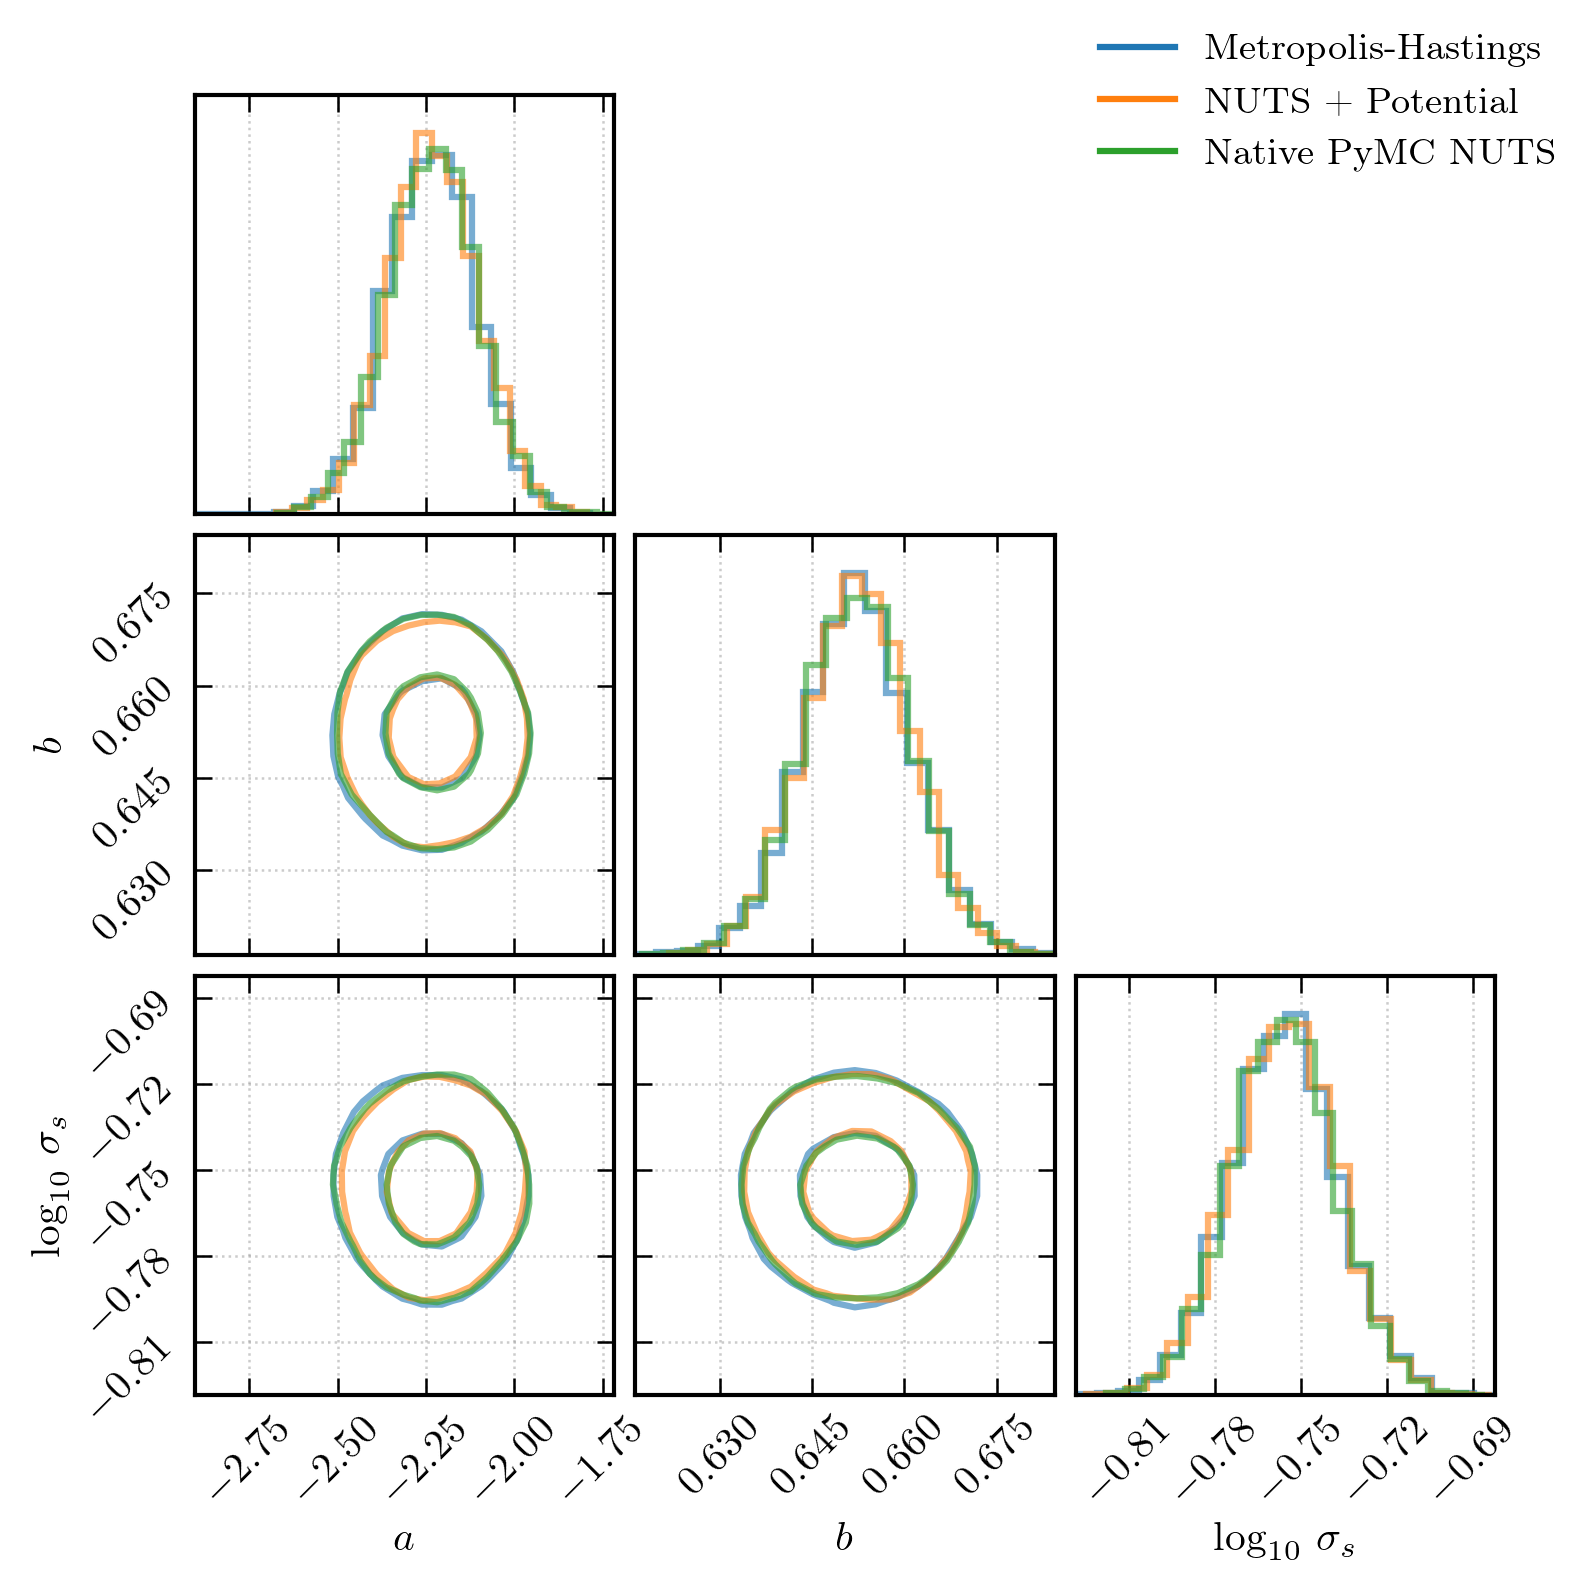

In [5]:
best_row = rrab_proposal_scan.loc[(rrab_proposal_scan["acceptance"] - 0.5).abs().idxmin()]
rrab_proposal_std = best_row["proposal_std"]
rrab_mh = mh_sample(rrab_ctx, rrab_proposal_std)

rrab_nuts_potential = nuts_potential_sample(rrab_ctx)

rrab_nuts_native = nuts_sample(LinearGaussianLikelihood(*build_pl_arrays(rrab_data, "M_G", "sigma_M")))

fig = plot_sampler_comparison_corner(rrab_mh, rrab_nuts_potential, rrab_nuts_native, "fig_methods_corner_rrab.pdf")
plt.show()

In [6]:
rrc_proposal_scan = []
for ps in mh_proposal_grid:
    result = mh_sample(rrc_ctx, ps, n_steps=4_000, n_burn=500)
    rrc_proposal_scan.append({"proposal_std": ps.tolist(), "acceptance": round(result.acceptance_rate, 3)})
rrc_proposal_scan = pd.DataFrame(rrc_proposal_scan)
rrc_proposal_scan

,proposal_std,acceptance
0,"[0.084, 0.007, 0.007]",0.691
1,"[0.096, 0.008, 0.008]",0.653
2,"[0.108, 0.009, 0.009]",0.619
3,"[0.12, 0.01, 0.01]",0.584
4,"[0.132, 0.011, 0.011]",0.546


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, b, log10_sig]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


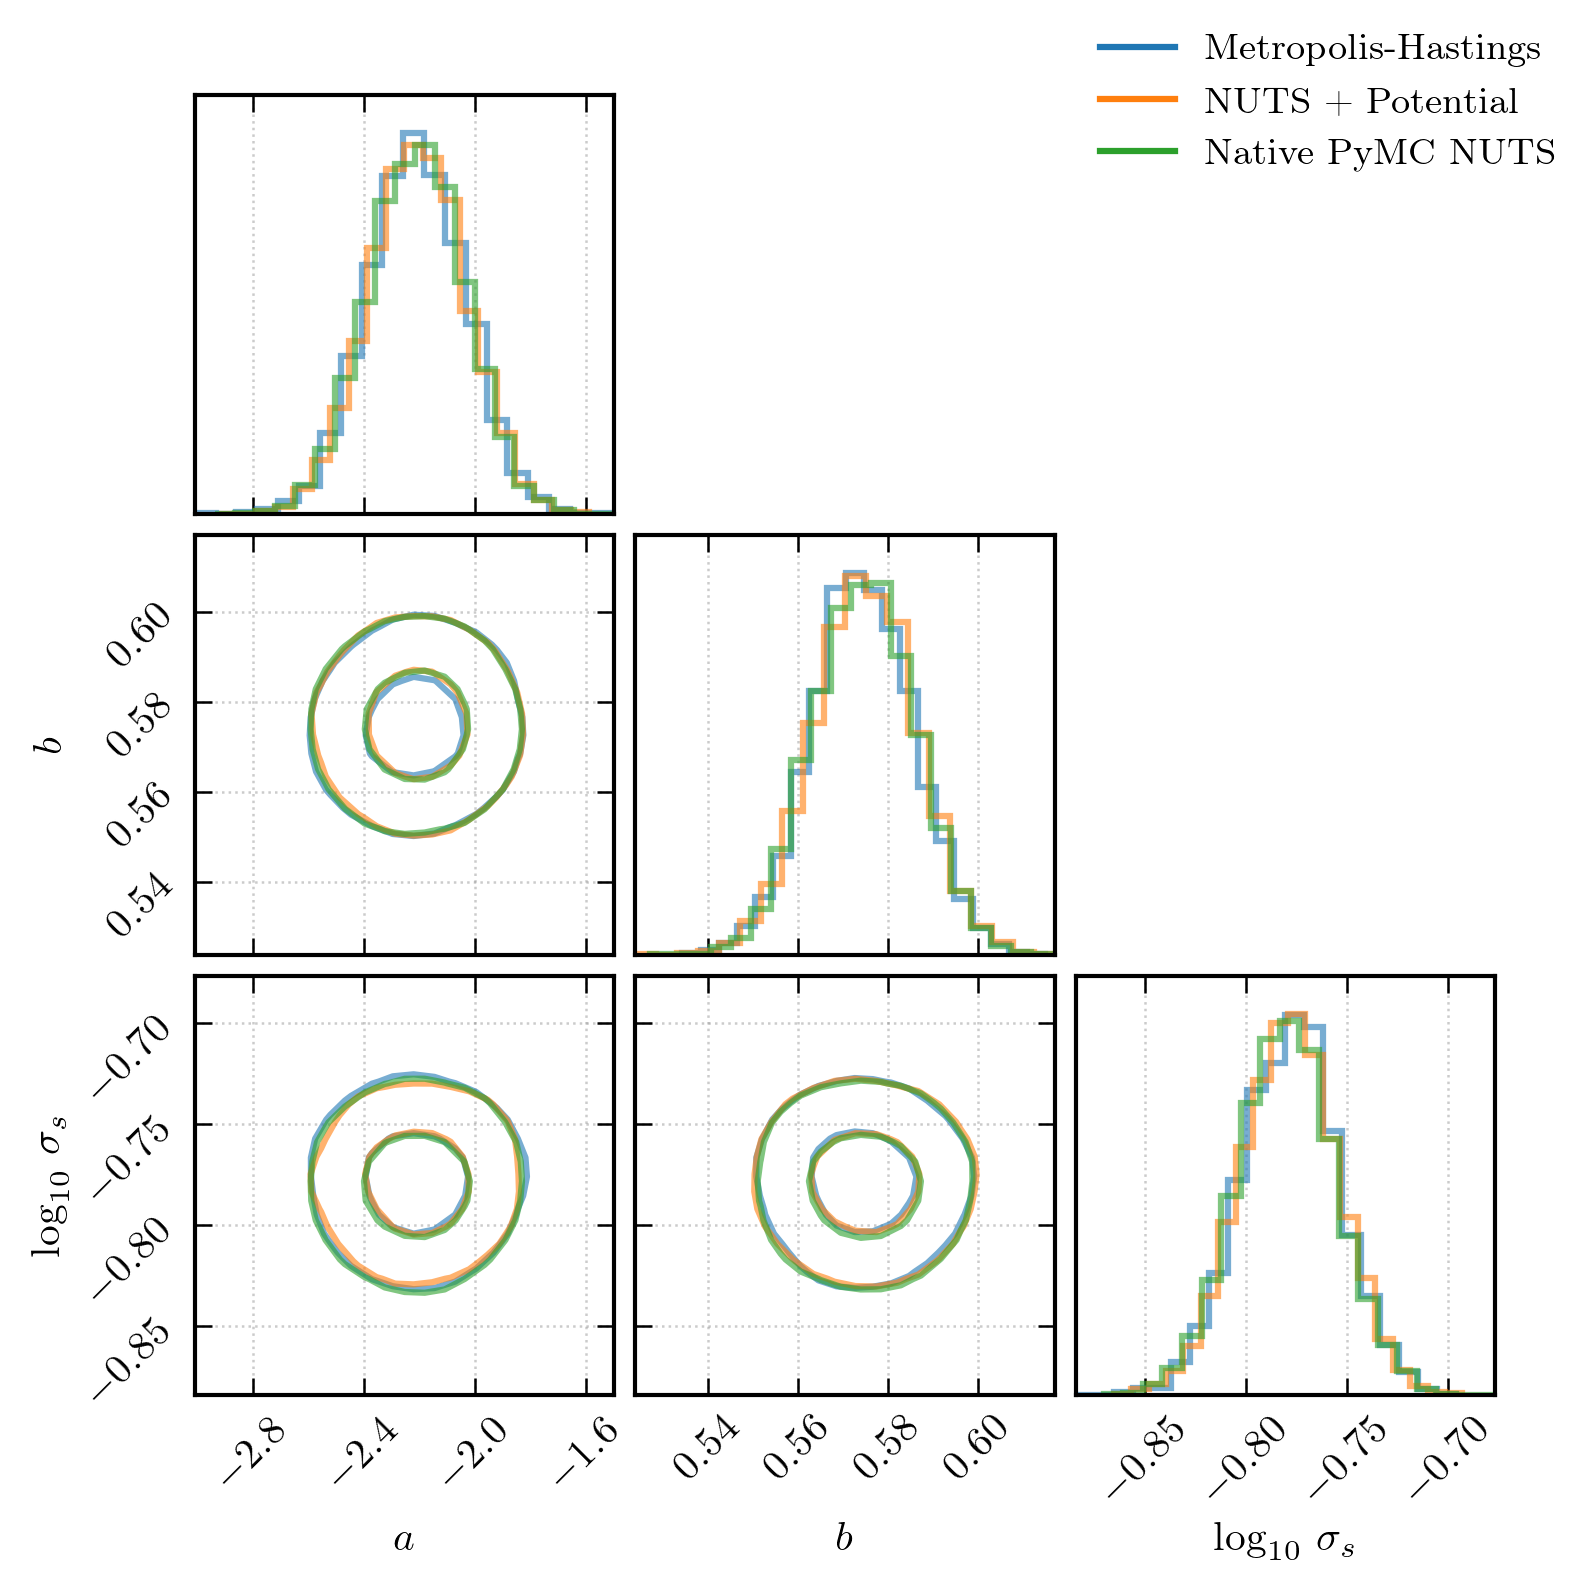

In [7]:
best_row = rrc_proposal_scan.loc[(rrc_proposal_scan["acceptance"] - 0.5).abs().idxmin()]
rrc_proposal_std = best_row["proposal_std"]
rrc_mh = mh_sample(rrc_ctx, rrc_proposal_std)

rrc_nuts_potential = nuts_potential_sample(rrc_ctx)

rrc_nuts_native = nuts_sample(LinearGaussianLikelihood(*build_pl_arrays(rrc_data, "M_G", "sigma_M")))

fig = plot_sampler_comparison_corner(rrc_mh, rrc_nuts_potential, rrc_nuts_native, "fig_methods_corner_rrc.pdf")
plt.show()